## Supervised Classification!

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
sampleData = pd.read_csv("news_AP.csv")
sampleData.head()

,title,topic
0,Terminally ill Connecticut woman ends her life...,Healthcare
1,King Charles III will have a prostate operatio...,Healthcare
2,Community health centers serve 1 in 11 America...,Healthcare
3,Washington state reaches a nearly $150 million...,Healthcare
4,Community health centers serve 1 in 11 America...,Healthcare


## Vectorize documents (the ‘title’ column in the provided data) using both TF-IDF and distributed embedding techniques

In [93]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

### TF-IDF Vectorized Documents

In [94]:
# tokenize the titles of each article
title_col = sampleData["title"]
title_tokenized = []
for title in title_col:
    tokenizer = CountVectorizer().build_tokenizer()
    title_tokenized.append(tokenizer(title))
    
print(len(title_tokenized))
print(title_tokenized)


199
[['Terminally', 'ill', 'Connecticut', 'woman', 'ends', 'her', 'life', 'on', 'her', 'own', 'terms', 'in', 'Vermont'], ['King', 'Charles', 'III', 'will', 'have', 'prostate', 'operation', 'next', 'week', 'while', 'Kate', 'recovers', 'from', 'abdominal', 'surgery'], ['Community', 'health', 'centers', 'serve', 'in', '11', 'Americans', 'They', 're', 'safety', 'net', 'under', 'stress'], ['Washington', 'state', 'reaches', 'nearly', '150', 'million', 'settlement', 'with', 'Johnson', 'Johnson', 'over', 'opioid', 'crisis'], ['Community', 'health', 'centers', 'serve', 'in', '11', 'Americans', 'They', 're', 'safety', 'net', 'under', 'stress'], ['Defense', 'Secretary', 'Lloyd', 'Austin', 'returns', 'to', 'work', 'at', 'the', 'Pentagon', 'after', 'cancer', 'surgery', 'complications'], ['Maker', 'of', 'recalled', 'sleep', 'apnea', 'machines', 'agrees', 'to', 'halt', 'sales', 'in', 'US'], ['NOT', 'REAL', 'NEWS', 'look', 'at', 'what', 'didn', 'happen', 'this', 'week'], ['Austin', 'kept', 'prostate',

In [95]:
# stemming the text
# initialize stemmer
stemmer = SnowballStemmer("english")

# apply stemming for title
stemmed_tokens_t = [] # empty list to store stemmed tokens

for title in title_tokenized:
    stem_single_title = []
    for token in title:
        stemmed = stemmer.stem(token)
        stem_single_title.append(stemmed)
    stemmed_tokens_t.append(stem_single_title)

In [96]:
# stopword removal

# get English stopwords
stop_words = set(stopwords.words('english'))

# remove stop words for title
filtered_tokens_t = [] # empty list to store stemmed tokens
for title in stemmed_tokens_t:
    temp_list = []
    # "token", in this case, would be the individual words of the title
    for token in title:
        if token not in stop_words:
            temp_list.append(token)
    filtered_tokens_t.append(temp_list)

In [97]:
# create DTM with tf-idf weighting scheme

# helps to capture word frequency of all documents

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# join tokens back into string for DTM and tf-idf

# list comprehension to join the indivdual tokens of each article title
joined_title = [' '.join(token) for token in filtered_tokens_t]

# DTM's rows are the documents and the columns are the unique words

# build the DTM with tf-idf
vectorizer = TfidfVectorizer()
dtm_tfidf = vectorizer.fit_transform(joined_title)

# this would be X in this case
dtm_tfidf

<199x907 sparse matrix of type '<class 'numpy.float64'>'
	with 2017 stored elements in Compressed Sparse Row format>

### Embedded Documents/Sentences

In [98]:
from sentence_transformers import SentenceTransformer

# load pre-trained transformer model that captures semantic meanings of words, instead of frequency
model = SentenceTransformer("all-MiniLM-L6-v2")

# loading the documents into a list
# could have used .tolist() instead
documents = []
for title in sampleData["title"]:
    documents.append(title)

# compute document embeddings
doc_embeddings = model.encode(documents)

## Train a classifier using Random Forest with both vectorization methods and compare their performance.


### TF-IDF Random Forest Classifier

### Split the data into two parts (80/20):


In [99]:
# target labels
y = sampleData["topic"].tolist()
# print(y)

# setting tf-idf matrix as X
# these contain the features to predict the classified labels
X = dtm_tfidf

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
# train, test, split the tf-idf and labels
X_modeling, X_test, y_modeling, y_test = train_test_split(X, y, test_size = 0.2, random_state = 7, stratify = y)

### Tune Hyperparameters and do K-folds cross validation

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [103]:
# create the hyper parameter to tune
tuned_parameters = {
        "n_estimators" : [10, 25, 50, 100], "max_depth" : [None, 5, 10, 20]
    }

# create a random forest classifier model
randomForest = RandomForestClassifier(random_state=7)

# setting up the grid search object to tune hyperparameters to find the best settings
# uses the random forest model to run all testing and training across folds and hyper parameters
# scores each combination using average f1 score
grid_search = GridSearchCV(randomForest, tuned_parameters, cv = 5, scoring = "f1_macro")
print(type(grid_search))

# trains the model using the training data for the X and y (tf-idf and labels)
# creates a random forests for each combination of hyperparameters for each fold
# although grid search is a random forest, it is still using grid search features that I chose to go through and select best features
grid_search.fit(X_modeling, y_modeling)

# prints out the best hyper parameter combination through its hidden average f1 score evaluations
print("Best Hyperparameters:", grid_search.best_params_)

# saves the best performing parameter of trained random forest model
model = grid_search.best_estimator_
print(type(model))

# 3 folds would give 25 n_estimators
# 4, 5 folds would give 50 n_estimators

<class 'sklearn.model_selection._search.GridSearchCV'>
Best Hyperparameters: {'max_depth': None, 'n_estimators': 50}
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [104]:
# print out the random forest classifier model with best attributes
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

### Predict Using the Model and Visualize High Importance Words

In [105]:
from sklearn.metrics import classification_report

# uses the test data split of the X (TF-IDF) to try and predict the label using the best random forest model
y_pred = model.predict(X_test)
print(len(y_pred))

# model performance same for all folds, 20% of original data
print(classification_report(y_test, y_pred))

40
                   precision    recall  f1-score   support

          Animals       1.00      0.20      0.33        10
       Healthcare       0.80      0.67      0.73         6
Sports - Football       0.62      1.00      0.76        16
   Transportation       1.00      0.88      0.93         8

         accuracy                           0.72        40
        macro avg       0.85      0.69      0.69        40
     weighted avg       0.82      0.72      0.68        40



907


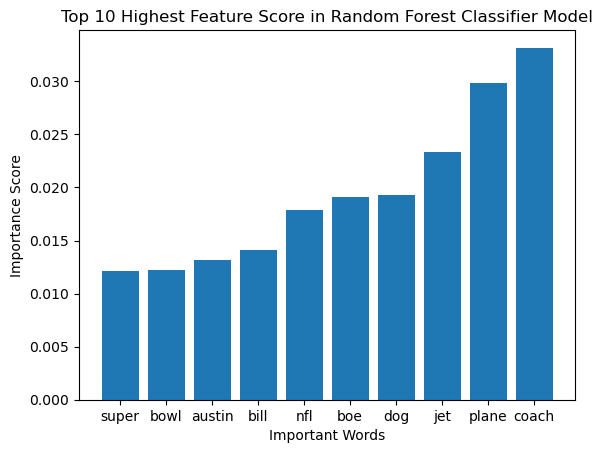

In [106]:
# visualize feature importance for the top 10 with the highest score
importance = model.feature_importances_

# get the actual word features from the vectorizer
feature_names = vectorizer.get_feature_names_out()
print(len(feature_names))

# extract the 10 most important features using argsort to get the indices of top 10 highest sorted importance scores
top_indices = np.argsort(importance)[-10:]
# use the indices to subset the feature names and corresponding importance scores
top_features = feature_names[top_indices]
top_scores = importance[top_indices]

plt.bar(top_features, top_scores)
plt.title("Top 10 Highest Feature Score in Random Forest Classifier Model")
plt.xlabel("Important Words")
plt.ylabel("Importance Score")
plt.show()

In [107]:
# just for my own practice and learning
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 5, scoring = "accuracy")
print(scores)
print("Average Cross Validation accuracy:", scores.mean())

[0.8        0.875      0.725      0.975      0.82051282]
Average Cross Validation accuracy: 0.839102564102564


### Embedded Documents Random Forest Classifier

In [108]:
X2 = doc_embeddings

In [109]:
X_modeling2, X_test2, y_modeling2, y_test2 = train_test_split(X2, y, test_size = 0.2, random_state = 7, stratify = y)

In [110]:
# create the hyper parameter to tune
tuned_parameters = {
        "n_estimators" : [10, 25, 50, 100], "max_depth" : [None, 5, 10, 20]
    }

# create a random forest classifier model
randomForest2 = RandomForestClassifier(random_state=7)

# setting up the grid search object to tune hyperparameters to find the best settings
# uses the random forest model to run all testing and training across folds and hyper parameters
# scores each combination using average f1 score
grid_search2 = GridSearchCV(randomForest2, tuned_parameters, cv = 5, scoring = "f1_macro")
print(type(grid_search2)) # output is a grid search object that wraps a random forest model, can be used train data

# trains the model using the training data for the X and y (tf-idf and labels)
# creates a random forests for each combination of hyperparameters for each fold
grid_search2.fit(X_modeling2, y_modeling2)

# prints out the best hyper parameter combination through its hidden average f1 score evaluations
# done from us fitting with our training data first
print("Best Hyperparameters:", grid_search2.best_params_)

# saves the best performing parameter of random forest model
model2 = grid_search2.best_estimator_
print(type(model2))

<class 'sklearn.model_selection._search.GridSearchCV'>
Best Hyperparameters: {'max_depth': None, 'n_estimators': 50}
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [111]:
model2

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [112]:
from sklearn.metrics import classification_report

# uses the test data split of the X (TF-IDF) to try and predict the label using the best random forest model
y_pred2 = model2.predict(X_test2)
print(len(y_pred2))

# model performance same for all folds, 20% of original data
print(classification_report(y_test2, y_pred2))

40
                   precision    recall  f1-score   support

          Animals       1.00      0.90      0.95        10
       Healthcare       1.00      0.83      0.91         6
Sports - Football       0.89      1.00      0.94        16
   Transportation       1.00      1.00      1.00         8

         accuracy                           0.95        40
        macro avg       0.97      0.93      0.95        40
     weighted avg       0.96      0.95      0.95        40



In [113]:
# just for my own practice and learning
scores2 = cross_val_score(model2, X2, y, cv = 5, scoring = "accuracy")
print("Average CV accuracy:", scores2.mean())
print(scores2)

Average CV accuracy: 0.9448717948717948
[0.85       0.95       0.95       1.         0.97435897]


## Try doing feature selection through using feature importance

In [114]:
# extract the feature importance values and the feature names
importance = model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# merge the two variables into a pandas dataframe so that we can sort
# also have feature and importance value paired up side-by-side
feature_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
feature_df = feature_df.sort_values(by = "Importance", ascending = False)
feature_df

,Feature,Importance
181,coach,0.033161
624,plane,0.029880
433,jet,0.023292
256,dog,0.019305
124,boe,0.019073
...,...,...
672,receipt,0.000000
90,award,0.000000
164,challeng,0.000000
443,josh,0.000000


In [115]:
# select top features
# 600 provided highest performance score
best_features = feature_df["Feature"][:600].values

# turning the sparse vector training data to dataframe structure to subset using the target feature strings/names
X_modeling_df = pd.DataFrame.sparse.from_spmatrix(X_modeling, columns = feature_df["Feature"])
X_test_df = pd.DataFrame.sparse.from_spmatrix(X_test, columns = feature_df["Feature"])

# subsetting the best features from the X modeling and test data
X_modeling_features = X_modeling_df[best_features]
X_test_features = X_test_df[best_features]

In [116]:
# create the hyper parameter to tune
tuned_parameters3 = {
        "n_estimators" : [10, 25, 50, 100], "max_depth" : [None, 5, 10, 20]
    }

# create a random forest classifier model
randomForest3 = RandomForestClassifier(random_state=7)

# setting up the grid search object to tune hyperparameters to find the best settings
# uses the random forest model to run all testing and training across folds and hyper parameters
# scores each combination using average f1 score
grid_search3 = GridSearchCV(randomForest3, tuned_parameters3, cv = 5, scoring = "f1_macro")
print(type(grid_search3))

# trains the model using the training data for the X and y (tf-idf and labels)
# creates a random forests for each combination of hyperparameters for each fold
# although grid search is a random forest, it is still using grid search features that I chose to go through and select best features
grid_search3.fit(X_modeling_features, y_modeling)

# prints out the best hyper parameter combination through its hidden average f1 score evaluations
print("Best Hyperparameters:", grid_search3.best_params_)

# saves the best performing parameter of trained random forest model
model3 = grid_search3.best_estimator_
print(type(model3))

<class 'sklearn.model_selection._search.GridSearchCV'>
Best Hyperparameters: {'max_depth': None, 'n_estimators': 100}
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [117]:
model3

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [118]:
# uses the test data split of the X (TF-IDF) to try and predict the label using the best random forest model
y_pred3 = model3.predict(X_test_features)
print(len(y_pred3))

# model performance same for all folds, 20% of original data
print(classification_report(y_test, y_pred3))

40
                   precision    recall  f1-score   support

          Animals       1.00      0.50      0.67        10
       Healthcare       1.00      0.67      0.80         6
Sports - Football       0.73      1.00      0.84        16
   Transportation       0.89      1.00      0.94         8

         accuracy                           0.82        40
        macro avg       0.90      0.79      0.81        40
     weighted avg       0.87      0.82      0.81        40

